In [1]:
# Install kagglehub if not already available
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, glob, zipfile
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"        : 140,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "font.size"         : 11,
})

# Output folder for saving plots
SAVE_DIR = "/content/unemployment_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Libraries ready!")
print(f"📁 Plots will be saved to: {SAVE_DIR}")


✅ Libraries ready!
📁 Plots will be saved to: /content/unemployment_plots


In [2]:
# Download dataset
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")
print(f"✅ Dataset downloaded to: {path}")

# Auto-find the CSV file
csv_files = glob.glob(f"{path}/**/*.csv", recursive=True) + glob.glob(f"{path}/*.csv")
print(f"\n📄 CSV files found:")
for f in csv_files:
    print(f"   {f}")

DATASET_PATH = csv_files[0] if csv_files else None
print(f"\n▶ Using: {DATASET_PATH}")


100%|██████████| 16.0k/16.0k [00:00<00:00, 22.3MB/s]

Extracting files...
✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5

📄 CSV files found:
   /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment_Rate_upto_11_2020.csv
   /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment in India.csv
   /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment_Rate_upto_11_2020.csv
   /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment in India.csv

▶ Using: /root/.cache/kagglehub/datasets/gokulrajkmv/unemployment-in-india/versions/5/Unemployment_Rate_upto_11_2020.csv


In [3]:
df_raw = pd.read_csv(DATASET_PATH)
df_raw.columns = df_raw.columns.str.strip()
print("Raw columns:", list(df_raw.columns))
print(f"Raw shape  : {df_raw.shape}")
display(df_raw.head(3))


Raw columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
Raw shape  : (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74


In [4]:
df = df_raw.copy()

# Rename columns to short names
df.rename(columns={
    "Region"                               : "State",
    "Estimated Unemployment Rate (%)"      : "Unemployment_Rate",
    "Estimated Employed"                   : "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
    "Area"                                 : "Region",
}, inplace=True)

# Parse dates — handle both DD-MM-YYYY and YYYY-MM-DD
try:
    df["Date"] = pd.to_datetime(df["Date"].str.strip(), format="%d-%m-%Y")
except Exception:
    df["Date"] = pd.to_datetime(df["Date"].str.strip(), infer_datetime_format=True)

df["Month"]      = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b %Y")
df["Period"]     = df["Date"].apply(
    lambda d: "Pre-COVID"    if d < pd.Timestamp("2020-03-01")
    else ("Lockdown"         if d <= pd.Timestamp("2020-05-31")
    else "Post-Lockdown")
)

# Drop rows with missing key values
df.dropna(subset=["Unemployment_Rate","Employed","Labour_Participation_Rate"], inplace=True)

print("=" * 65)
print("  UNEMPLOYMENT ANALYSIS — CodeAlpha Task 2")
print("=" * 65)
print(f"\n  Shape         : {df.shape}")
print(f"  States        : {df['State'].nunique()}")
print(f"  Date Range    : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"\n  Statistical Summary:")
display(df[["Unemployment_Rate","Employed","Labour_Participation_Rate"]].describe().round(2))


  UNEMPLOYMENT ANALYSIS — CodeAlpha Task 2

  Shape         : (267, 12)
  States        : 27
  Date Range    : 2020-01-31 → 2020-10-31
  Missing Values: 0

  Statistical Summary:


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,267.00,267.00,267.00
mean,12.24,13962105.72,41.68
std,10.80,13366318.36,7.85
min,0.50,117542.00,16.77
25%,4.84,2838930.50,37.26
50%,9.65,9732417.00,40.39
75%,16.76,21878686.00,44.06
max,75.85,59433759.00,69.69


## 4.  National Trend — COVID-19 Impact

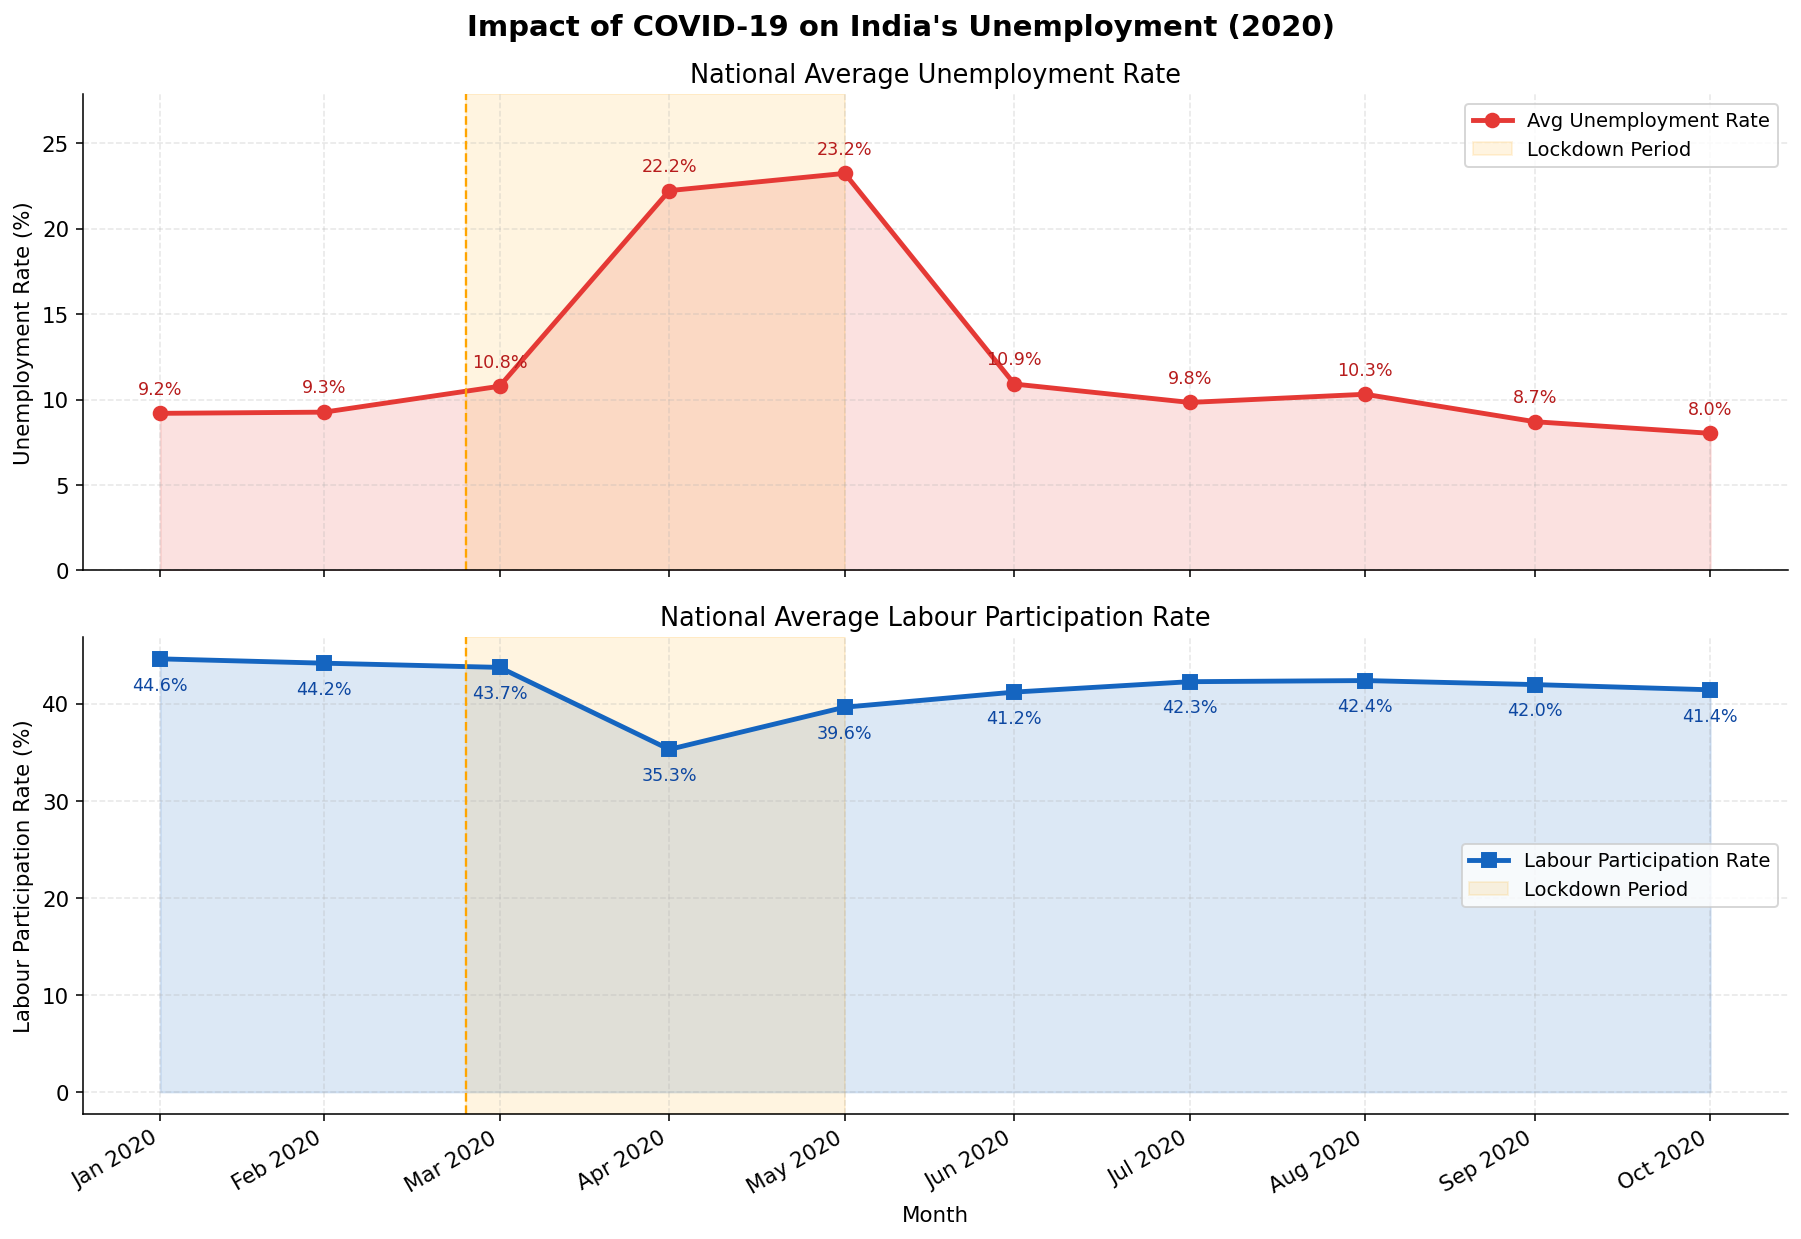

✅ Saved → /content/unemployment_plots/fig1_national_trend.png


In [5]:
monthly = (df.groupby("Date")
             .agg(Avg_Unemployment=("Unemployment_Rate","mean"),
                  Avg_LPR=("Labour_Participation_Rate","mean"),
                  Total_Employed=("Employed","sum"))
             .reset_index())

lockdown_start = pd.Timestamp("2020-03-25")
lockdown_end   = pd.Timestamp("2020-05-31")

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle("Impact of COVID-19 on India's Unemployment (2020)",
             fontsize=15, fontweight="bold", y=0.98)

# -- Unemployment Rate
ax1 = axes[0]
ax1.fill_between(monthly["Date"], monthly["Avg_Unemployment"], alpha=0.15, color="#E53935")
ax1.plot(monthly["Date"], monthly["Avg_Unemployment"],
         marker="o", color="#E53935", linewidth=2.5, markersize=7, label="Avg Unemployment Rate")
for _, row in monthly.iterrows():
    ax1.annotate(f'{row["Avg_Unemployment"]:.1f}%',
                 (row["Date"], row["Avg_Unemployment"]),
                 textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9, color="#B71C1C")
ax1.axvspan(lockdown_start, lockdown_end, alpha=0.12, color="orange", label="Lockdown Period")
ax1.axvline(lockdown_start, color="orange", linestyle="--", linewidth=1.2)
ax1.set_ylabel("Unemployment Rate (%)"); ax1.set_title("National Average Unemployment Rate")
ax1.legend(fontsize=10); ax1.set_ylim(0, monthly["Avg_Unemployment"].max() * 1.2)

# -- Labour Participation Rate
ax2 = axes[1]
ax2.fill_between(monthly["Date"], monthly["Avg_LPR"], alpha=0.15, color="#1565C0")
ax2.plot(monthly["Date"], monthly["Avg_LPR"],
         marker="s", color="#1565C0", linewidth=2.5, markersize=7, label="Labour Participation Rate")
for _, row in monthly.iterrows():
    ax2.annotate(f'{row["Avg_LPR"]:.1f}%',
                 (row["Date"], row["Avg_LPR"]),
                 textcoords="offset points", xytext=(0, -16),
                 ha="center", fontsize=9, color="#0D47A1")
ax2.axvspan(lockdown_start, lockdown_end, alpha=0.12, color="orange", label="Lockdown Period")
ax2.axvline(lockdown_start, color="orange", linestyle="--", linewidth=1.2)
ax2.set_ylabel("Labour Participation Rate (%)"); ax2.set_xlabel("Month")
ax2.set_title("National Average Labour Participation Rate"); ax2.legend(fontsize=10)

plt.xticks(monthly["Date"],
           [d.strftime("%b %Y") for d in monthly["Date"]], rotation=30, ha="right")
plt.tight_layout()
SAVE1 = f"{SAVE_DIR}/fig1_national_trend.png"
plt.savefig(SAVE1, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE1}")


## 5.  Pre-COVID vs Lockdown vs Post-Lockdown

Unemployment by Period:


,mean,median,max,min
Period,,,,
Pre-COVID,9.23,6.66,32.67,0.58
Lockdown,18.71,16.21,75.85,1.20
Post-Lockdown,9.56,8.34,33.50,0.50


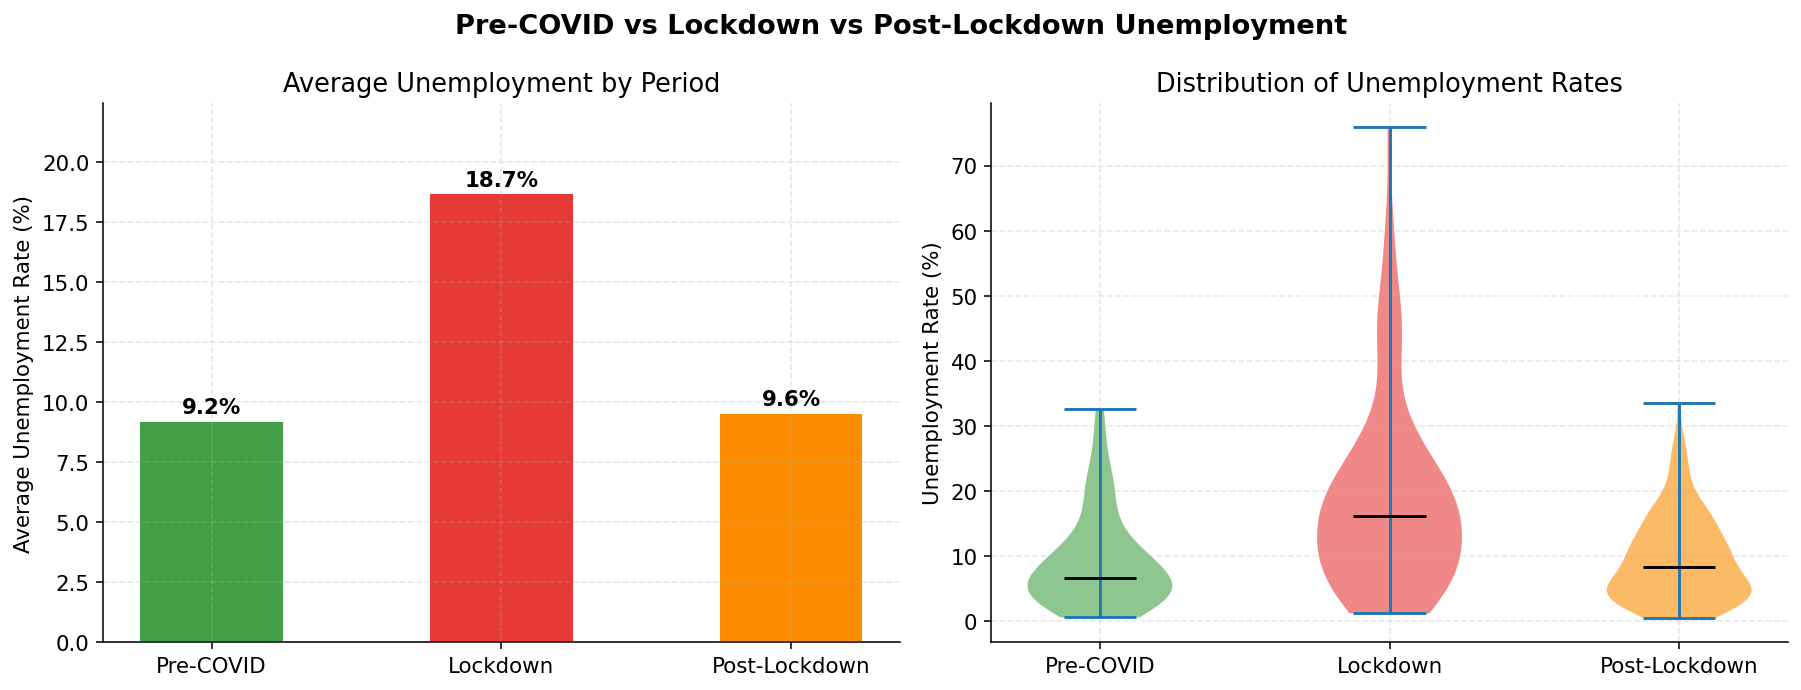

✅ Saved → /content/unemployment_plots/fig2_period_comparison.png


In [6]:
period_stats = (df.groupby("Period")["Unemployment_Rate"]
                  .agg(["mean","median","max","min"])
                  .round(2)
                  .reindex(["Pre-COVID","Lockdown","Post-Lockdown"]))
print("Unemployment by Period:")
display(period_stats)

colors  = {"Pre-COVID":"#43A047","Lockdown":"#E53935","Post-Lockdown":"#FB8C00"}
periods = ["Pre-COVID","Lockdown","Post-Lockdown"]
means   = [period_stats.loc[p,"mean"] for p in periods]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Pre-COVID vs Lockdown vs Post-Lockdown Unemployment",
             fontsize=14, fontweight="bold")

# Bar
ax = axes[0]
bars = ax.bar(periods, means, color=[colors[p] for p in periods], width=0.5, edgecolor="white")
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Unemployment Rate (%)"); ax.set_title("Average Unemployment by Period")
ax.set_ylim(0, max(means) * 1.2)

# Violin
ax2 = axes[1]
data_by_period = [df[df["Period"]==p]["Unemployment_Rate"].values for p in periods]
vp = ax2.violinplot(data_by_period, positions=[1,2,3], showmedians=True, showextrema=True)
for body, p in zip(vp["bodies"], periods):
    body.set_facecolor(colors[p]); body.set_alpha(0.6)
vp["cmedians"].set_color("black")
ax2.set_xticks([1,2,3]); ax2.set_xticklabels(periods)
ax2.set_ylabel("Unemployment Rate (%)"); ax2.set_title("Distribution of Unemployment Rates")

plt.tight_layout()
SAVE2 = f"{SAVE_DIR}/fig2_period_comparison.png"
plt.savefig(SAVE2, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE2}")


## 7.  State-wise Unemployment Heatmap

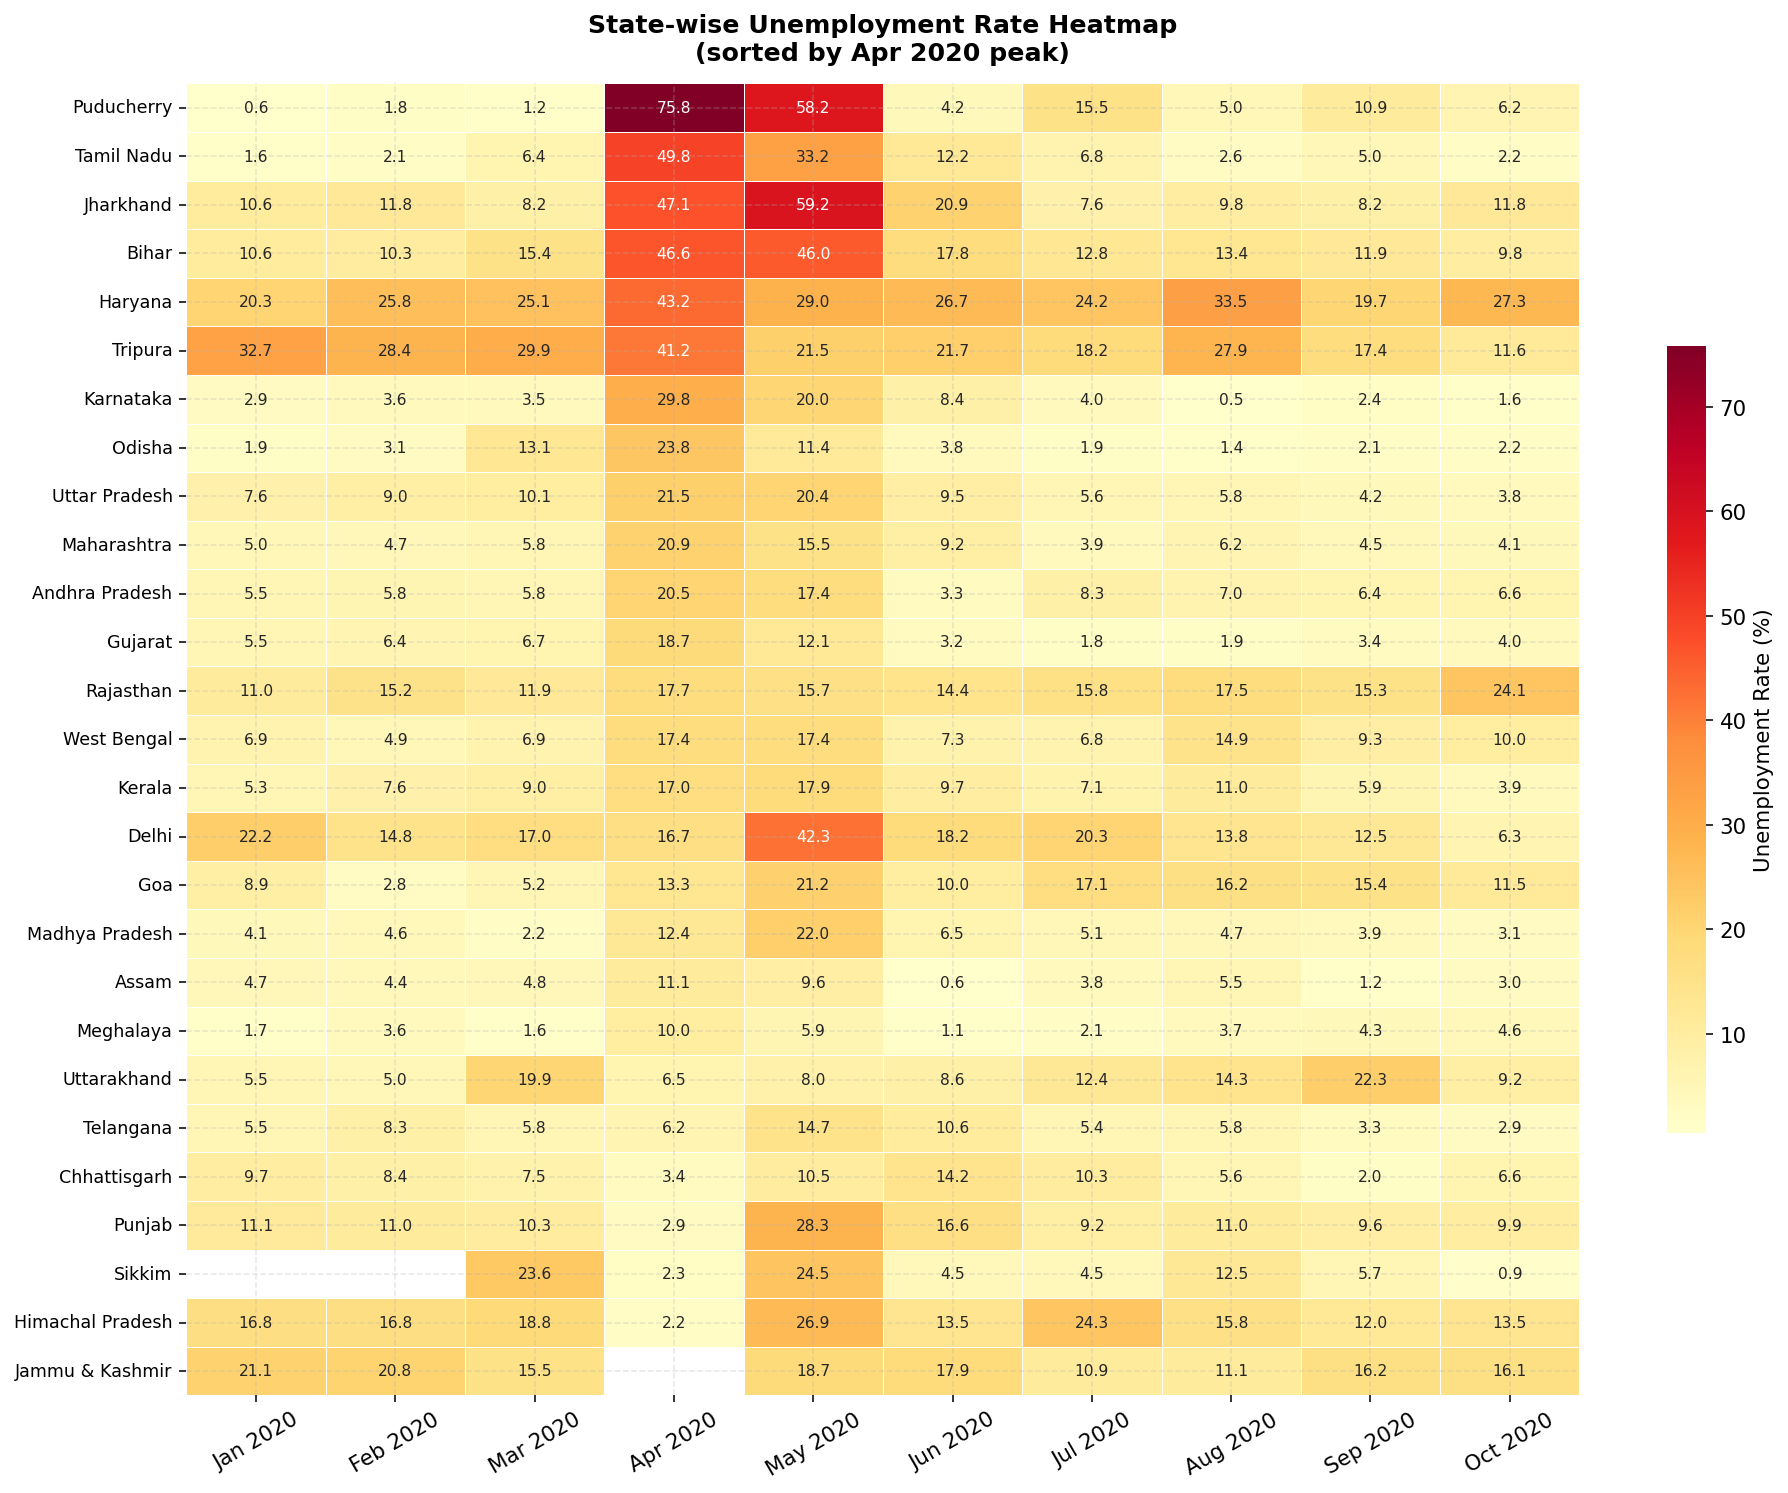

✅ Saved → /content/unemployment_plots/fig4_state_heatmap.png


In [8]:
# Build month order dynamically from actual data
all_months = df["Month_Name"].unique().tolist()
month_order_full = ["Jan 2020","Feb 2020","Mar 2020","Apr 2020","May 2020",
                    "Jun 2020","Jul 2020","Aug 2020","Sep 2020","Oct 2020",
                    "Nov 2020","Dec 2020"]
month_order = [m for m in month_order_full if m in all_months]

pivot = df.pivot_table(index="State", columns="Month_Name",
                       values="Unemployment_Rate", aggfunc="mean")
pivot = pivot[[m for m in month_order if m in pivot.columns]]

# Sort by peak lockdown month
sort_col = "Apr 2020" if "Apr 2020" in pivot.columns else pivot.columns[3]
pivot_sorted = pivot.sort_values(sort_col, ascending=False)

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot_sorted)*0.4)))
sns.heatmap(pivot_sorted, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label":"Unemployment Rate (%)","shrink":0.6},
            ax=ax, annot_kws={"size":8})
ax.set_title(f"State-wise Unemployment Rate Heatmap\n(sorted by {sort_col} peak)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0, labelsize=9)
plt.tight_layout()
SAVE4 = f"{SAVE_DIR}/fig4_state_heatmap.png"
plt.savefig(SAVE4, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE4}")


## 8.  Most vs Least Affected States

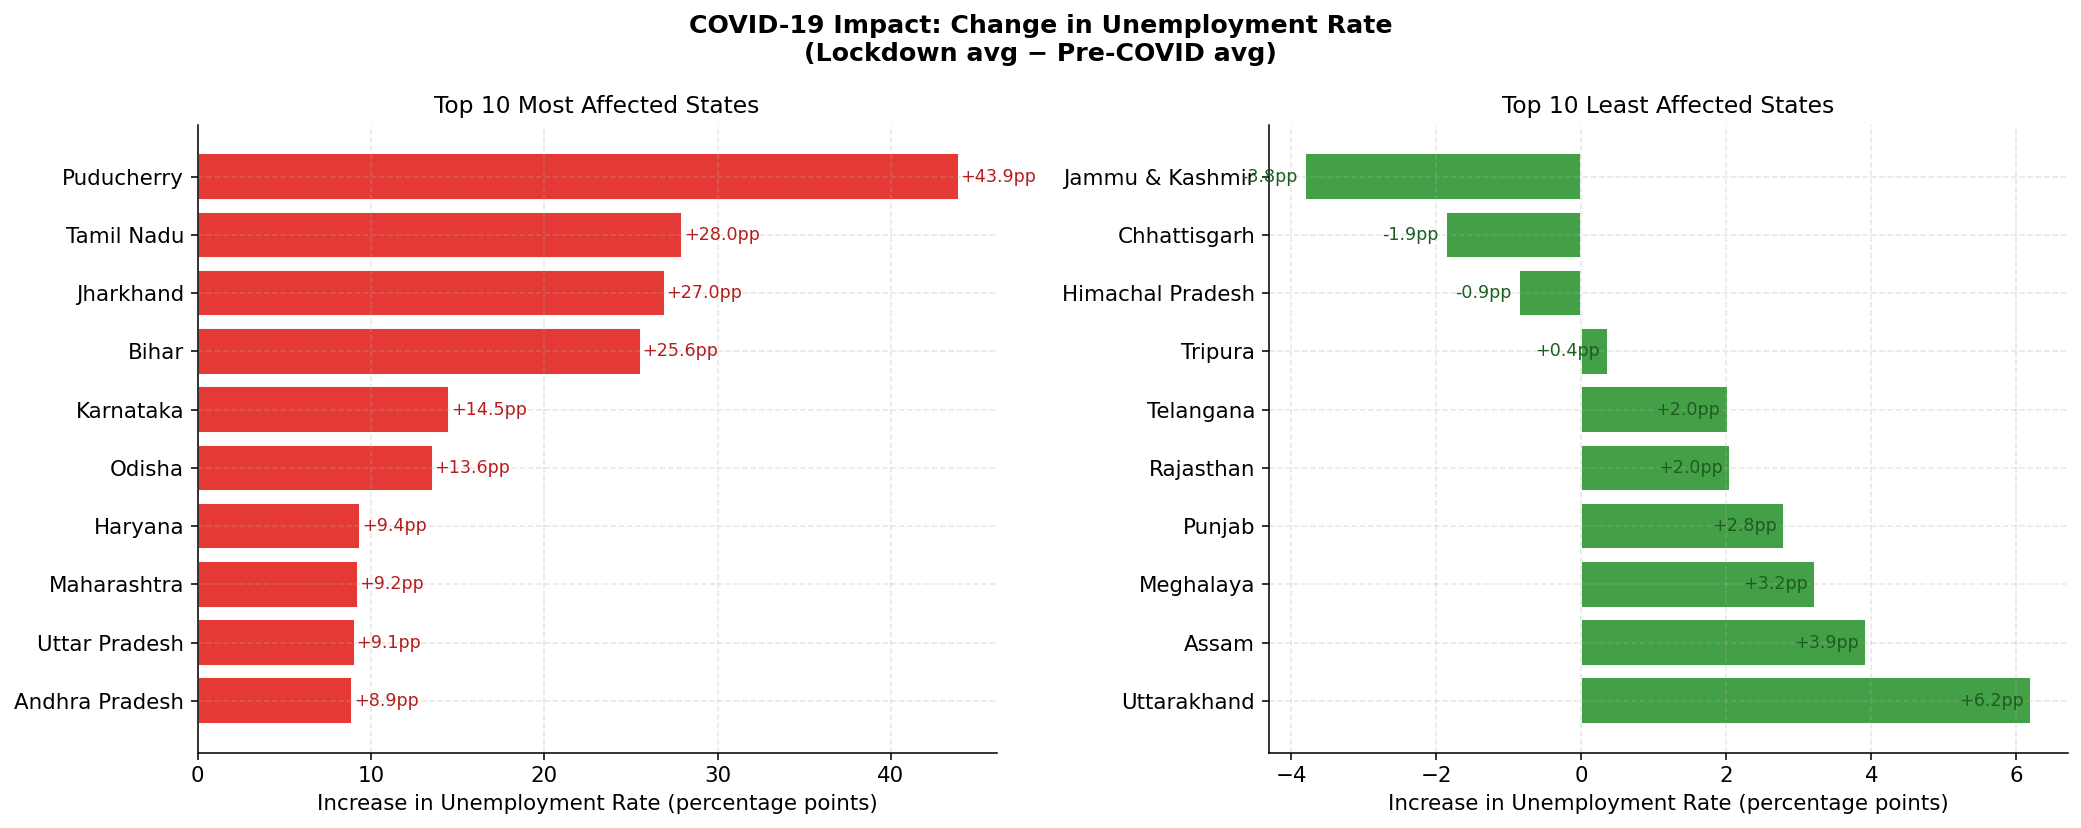

✅ Saved → /content/unemployment_plots/fig5_state_impact.png


In [10]:
covid_peak = df[df["Period"]=="Lockdown"].groupby("State")["Unemployment_Rate"].mean()
pre_covid  = df[df["Period"]=="Pre-COVID"].groupby("State")["Unemployment_Rate"].mean()

# Keep only states present in both periods
common_states = covid_peak.index.intersection(pre_covid.index)
impact = (covid_peak[common_states] - pre_covid[common_states]).sort_values(ascending=False)

top10    = impact.head(10)
bottom10 = impact.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("COVID-19 Impact: Change in Unemployment Rate\n(Lockdown avg − Pre-COVID avg)",
             fontsize=13, fontweight="bold")

ax1 = axes[0]
bars = ax1.barh(top10.index[::-1], top10.values[::-1], color="#E53935", edgecolor="white")
for bar, val in zip(bars, top10.values[::-1]):
    ax1.text(val+0.1, bar.get_y()+bar.get_height()/2,
             f"+{val:.1f}pp", va="center", fontsize=9, color="#B71C1C")
ax1.set_title("Top 10 Most Affected States", fontsize=12)
ax1.set_xlabel("Increase in Unemployment Rate (percentage points)")

ax2 = axes[1]
bars2 = ax2.barh(bottom10.index, bottom10.values, color="#43A047", edgecolor="white")
for bar, val in zip(bars2, bottom10.values):
    sign = "+" if val >= 0 else ""
    ax2.text(val-0.1, bar.get_y()+bar.get_height()/2,
             f"{sign}{val:.1f}pp", va="center", ha="right", fontsize=9, color="#1B5E20")
ax2.set_title("Top 10 Least Affected States", fontsize=12)
ax2.set_xlabel("Increase in Unemployment Rate (percentage points)")

plt.tight_layout()
SAVE5 = f"{SAVE_DIR}/fig5_state_impact.png"
plt.savefig(SAVE5, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE5}")


## 9.  Correlation

## 10. 📦 Monthly Distribution — Boxplot

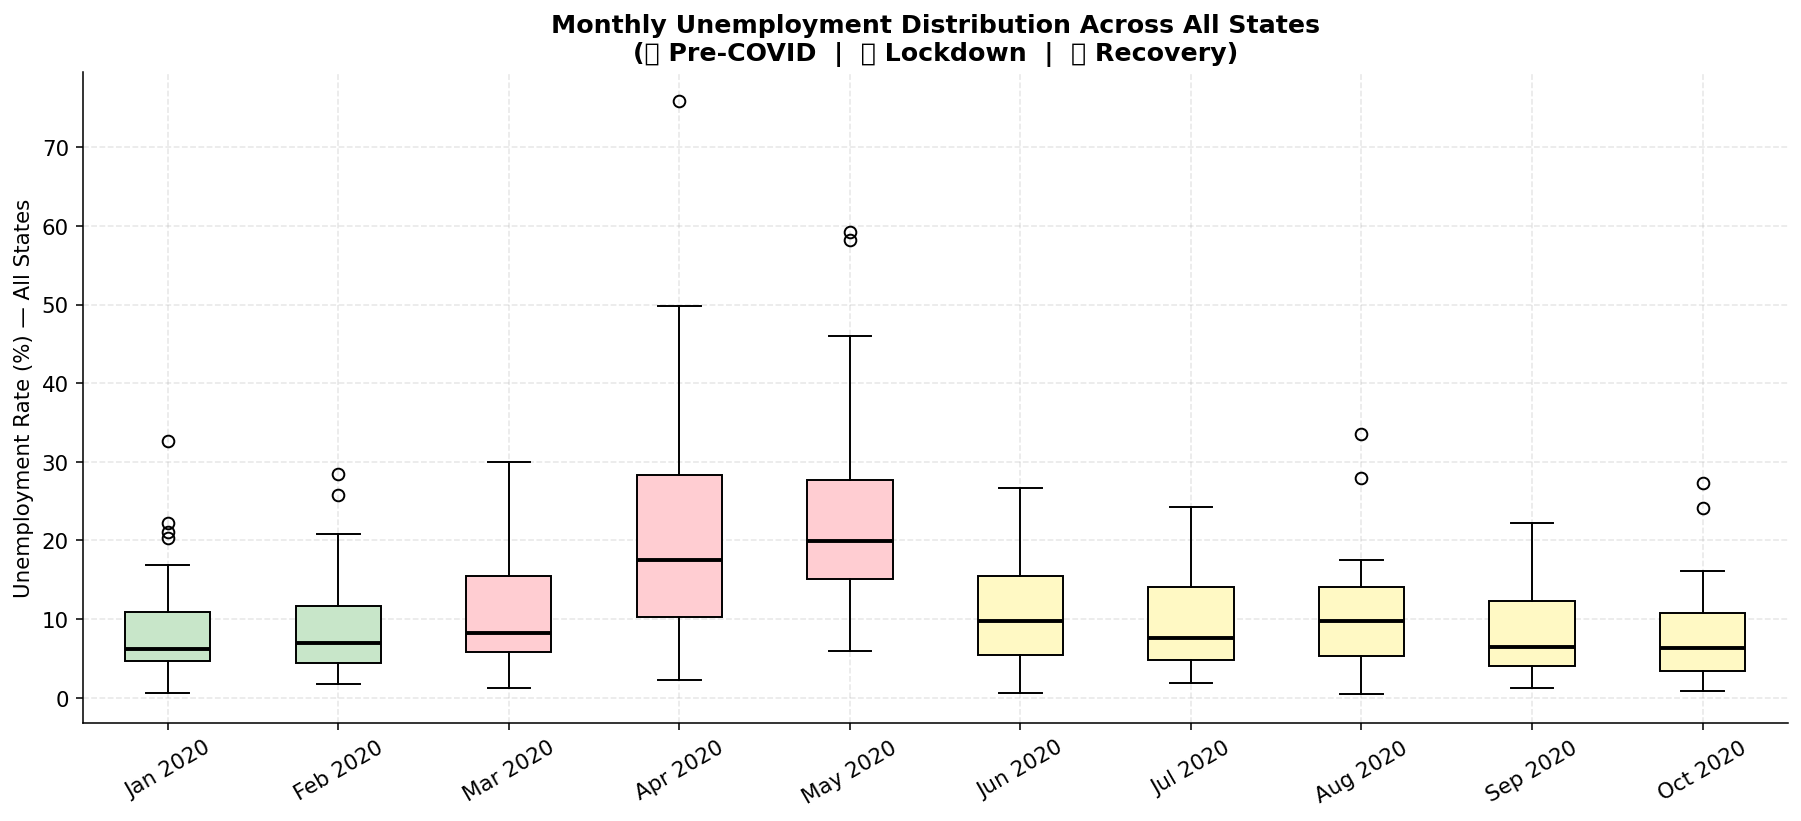

✅ Saved → /content/unemployment_plots/fig7_monthly_distribution.png


In [13]:
months_order    = [m for m in month_order if m in df["Month_Name"].unique()]
data_by_month   = [df[df["Month_Name"]==m]["Unemployment_Rate"].values for m in months_order]
lockdown_months = ["Mar 2020","Apr 2020","May 2020"]
pre_months      = ["Jan 2020","Feb 2020"]

fig, ax = plt.subplots(figsize=(13, 6))
bp = ax.boxplot(data_by_month, labels=months_order, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))

for patch, label in zip(bp["boxes"], months_order):
    if label in lockdown_months:       patch.set_facecolor("#FFCDD2")
    elif label in pre_months:          patch.set_facecolor("#C8E6C9")
    else:                              patch.set_facecolor("#FFF9C4")

ax.set_ylabel("Unemployment Rate (%) — All States", fontsize=11)
ax.set_title("Monthly Unemployment Distribution Across All States\n"
             "(🟢 Pre-COVID  |  🔴 Lockdown  |  🟡 Recovery)",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
SAVE7 = f"{SAVE_DIR}/fig7_monthly_distribution.png"
plt.savefig(SAVE7, bbox_inches="tight")
plt.show()
print(f"✅ Saved → {SAVE7}")


## 11. 💡 Key Insights Summary

In [14]:
pre_avg        = df[df["Period"]=="Pre-COVID"]["Unemployment_Rate"].mean()
lock_avg       = df[df["Period"]=="Lockdown"]["Unemployment_Rate"].mean()
post_avg       = df[df["Period"]=="Post-Lockdown"]["Unemployment_Rate"].mean()
peak_row       = df.loc[df["Unemployment_Rate"].idxmax()]
most_impacted  = impact.idxmax()
least_impacted = impact.idxmin()

print("=" * 65)
print("  KEY INSIGHTS — Unemployment Analysis (India 2020)")
print("=" * 65)
print(f"\n  📌 Pre-COVID avg      : {pre_avg:.2f}%")
print(f"  🔴 Lockdown avg       : {lock_avg:.2f}%   (↑ +{lock_avg-pre_avg:.2f} pp spike)")
print(f"  🟡 Post-Lockdown avg  : {post_avg:.2f}%   (recovery phase)")
print(f"\n  🏔️  Peak rate          : {peak_row['Unemployment_Rate']:.2f}% — "
      f"{peak_row['State']} ({peak_row['Month_Name']})")
print(f"  🔴 Most impacted      : {most_impacted}  (+{impact[most_impacted]:.2f} pp)")
print(f"  🟢 Least impacted     : {least_impacted}  (+{impact[least_impacted]:.2f} pp)")
print(f"\n  📊 Correlation (Unemployment vs LPR): {corr:.3f}")
print(f"     → Negative: as participation drops, unemployment spikes")
print(f"       (discouraged worker effect during lockdown)")
print("\n  Policy Recommendations:")
print("  1. States like Jharkhand & Bihar need targeted employment schemes")
print("  2. Labour participation programs essential for marginalised workers")
print("  3. Regional safety nets needed — North & East most vulnerable")
print("=" * 65)


  KEY INSIGHTS — Unemployment Analysis (India 2020)

  📌 Pre-COVID avg      : 9.23%
  🔴 Lockdown avg       : 18.71%   (↑ +9.48 pp spike)
  🟡 Post-Lockdown avg  : 9.56%   (recovery phase)

  🏔️  Peak rate          : 75.85% — Puducherry (Apr 2020)
  🔴 Most impacted      : Puducherry  (+43.91 pp)
  🟢 Least impacted     : Jammu & Kashmir  (+-3.81 pp)

  📊 Correlation (Unemployment vs LPR): -0.074
     → Negative: as participation drops, unemployment spikes
       (discouraged worker effect during lockdown)

  Policy Recommendations:
  1. States like Jharkhand & Bihar need targeted employment schemes
  2. Labour participation programs essential for marginalised workers
  3. Regional safety nets needed — North & East most vulnerable
